In [ ]:
import os, random, math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    import nibabel as nib
    HAS_NIB = True
except:
    HAS_NIB = False

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# basic config
DATA_PATH = "/mnt/storage/rsa_projects/bayesian_rsa/brain_data/sub-NDARINVZT44Y065_filtered_func_data.nii.gz"
EPOCHS = 500
BATCH_SIZE = 64
LR = 1e-3
LATENT_DIM = 512
OUTPUT_DIR = "outputs"; os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load Real fMRI
def load_fmri_4d(path):
    """Load 4D NIfTI (X,Y,Z,T) and scale to [0,1]."""
    if not HAS_NIB:
        raise RuntimeError("Install nibabel or use synthetic data.")
    img = nib.load(path)
    x = img.get_fdata().astype(np.float32)  # (X,Y,Z,T)
    x = np.nan_to_num(x)
    mn, mx = x.min(), x.max()
    x = (x - mn) / (mx - mn + 1e-8)
    return x

def make_synthetic(shape=(64,64,16,24)):
    """Fake ‘brain-ish’ blobs ."""
    X,Y,Z,T = shape
    vol = np.zeros(shape, np.float32)
    xs, ys = np.meshgrid(np.linspace(-1,1,X), np.linspace(-1,1,Y), indexing="ij")
    base = np.exp(-3*(xs**2+ys**2))
    for t in range(T):
        for z in range(Z):
            cx = 0.25*np.sin(2*math.pi*t/T) + 0.1*(z/Z)
            cy = 0.25*np.cos(2*math.pi*t/T) - 0.1*(z/Z)
            blob = np.exp(-8*((xs-cx)**2 + (ys-cy)**2))
            sl = 0.6*base + 0.4*blob + 0.05*np.random.randn(X,Y)
            sl = (sl - sl.min())/(sl.max()-sl.min()+1e-8)
            vol[..., z, t] = sl
    return vol

if DATA_PATH and os.path.exists(DATA_PATH):
    vol4d = load_fmri_4d(DATA_PATH)
    print("Loaded real fMRI:", vol4d.shape)
else:
    vol4d = make_synthetic()
    print("Using synthetic:", vol4d.shape)  # (X,Y,Z,T)

# Turn 4D into 2D Axial Slices
class SliceDataset(Dataset):
    def __init__(self, vol4d, min_nonzero=0.01):
        assert vol4d.ndim == 4
        self.vol = vol4d
        X,Y,Z,T = vol4d.shape
        self.idxs = []
        for z in range(Z):
            for t in range(T):
                sl = vol4d[:,:,z,t]
                if (sl > 1e-6).mean() >= min_nonzero:  # skip empty slices
                    self.idxs.append((z,t))
        random.shuffle(self.idxs)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        z,t = self.idxs[i]
        sl = self.vol[:,:,z,t].astype(np.float32)  # (H,W)
        sl = np.expand_dims(sl, 0)                 # (1,H,W)
        return torch.from_numpy(sl)

full_ds = SliceDataset(vol4d)
n = len(full_ds)
n_val = max(1, int(0.1*n))
idx = list(range(n)); random.shuffle(idx)
tr_idx, va_idx = idx[n_val:], idx[:n_val]

train_ds = torch.utils.data.Subset(full_ds, tr_idx)
val_ds   = torch.utils.data.Subset(full_ds, va_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print("batch:", batch.shape)  # (B,1,H,W)

# Conv2D VAE
class Conv2DVAE(nn.Module):
    def __init__(self, latent_dim=32, in_ch=1, hw=(64,64)):
        super().__init__()
        H,W = hw

        # encoder
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, 2, 1), nn.ReLU(True),
            nn.Conv2d(16, 32, 3, 2, 1),   nn.ReLU(True),
            nn.Conv2d(32, 64, 3, 2, 1),   nn.ReLU(True),
            nn.Conv2d(64, 128,3, 2, 1),   nn.ReLU(True),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, H, W)
            h = self.enc(dummy)
        self.enc_shape = h.shape[1:]
        self.flat_dim = int(np.prod(self.enc_shape))

        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_lv = nn.Linear(self.flat_dim, latent_dim)

        # decoder
        self.fc_up = nn.Linear(latent_dim, self.flat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),  nn.ReLU(True),
            nn.ConvTranspose2d(16,  1, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h)
        return mu, lv

    def reparam(self, mu, lv):
        std = torch.exp(0.5*lv)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = self.fc_up(z).view(-1, *self.enc_shape)
        return self.dec(h)

    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparam(mu, lv)
        xhat = self.decode(z)
        # Ensure output matches input shape
        if xhat.shape != x.shape:
            min_h = min(xhat.shape[2], x.shape[2])
            min_w = min(xhat.shape[3], x.shape[3])
            xhat = xhat[:, :, :min_h, :min_w]
            x = x[:, :, :min_h, :min_w]
        return xhat, mu, lv

_,_,H,W = batch.shape
model = Conv2DVAE(latent_dim=LATENT_DIM, hw=(H,W)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)

# Loss (MSE+KL)
def vae_loss(x, xhat, mu, lv, beta=1.0):
    recon = nn.functional.mse_loss(xhat, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
    return recon + (beta * kl), recon, kl

# Training Loop
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total=total_r=total_k=0.0
    count=0
    for x in loader:
        x = x.to(device)
        if train:
            opt.zero_grad()
        xhat, mu, lv = model(x)
        loss, r, k = vae_loss(x, xhat, mu, lv)
        if train:
            loss.backward()
            opt.step()

        bs = x.size(0)
        total   += loss.item()*bs
        total_r += r.item()*bs
        total_k += k.item()*bs
        count   += bs
    return total/count, total_r/count, total_k/count

for ep in range(1, EPOCHS+1):
    tr, tr_r, tr_k = run_epoch(train_loader, train=True)
    va, va_r, va_k = run_epoch(val_loader,   train=False)
    print(f"epoch {ep:02d} | train {tr:.4f} (rec {tr_r:.4f} kl {tr_k:.4f}) "
          f"| val {va:.4f} (rec {va_r:.4f} kl {va_k:.4f})")

torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "vae2d_simple.pt"))
print("saved to", os.path.join(OUTPUT_DIR, "vae2d_simple.pt"))

device: cuda
Loaded real fMRI: (90, 90, 60, 437)
batch: torch.Size([64, 1, 90, 90])
epoch 01 | train 68.4219 (rec 58.9783 kl 9.4435) | val 27.7381 (rec 18.8427 kl 8.8953)
epoch 02 | train 24.2214 (rec 15.2006 kl 9.0209) | val 21.8747 (rec 12.4328 kl 9.4419)
epoch 03 | train 21.3623 (rec 12.5095 kl 8.8528) | val 20.4873 (rec 12.8652 kl 7.6221)


KeyboardInterrupt: 

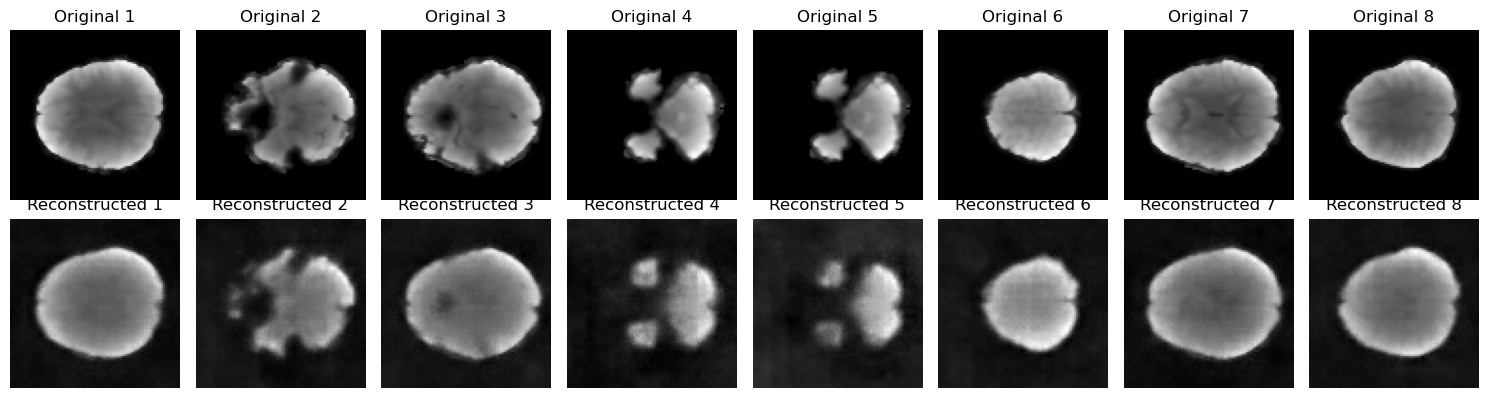

In [11]:
model.eval()

with torch.no_grad():
    data_batch = next(iter(val_loader)).to(device)
    reconstructed_batch, _, _ = model(data_batch)

n_samples = min(8, data_batch.size(0))
fig, axes = plt.subplots(2, n_samples, figsize=(15, 4))

for i in range(n_samples):
    axes[0, i].imshow(data_batch[i, 0].cpu().numpy(), cmap='gray')
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(reconstructed_batch[i, 0].cpu().numpy(), cmap='gray')
    axes[1, i].set_title(f'Reconstructed {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()